In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)

model_data = pd.read_csv(
    r"C:\Users\Adity\OneDrive\Desktop\RESEARCH\Project Work\Inflation-Forecasting-Dashboard\data\processed\model_sample_cpi_wpi.csv",
    parse_dates=["date"]
)

print("Shape:", model_data.shape)
display(model_data.head())
display(model_data.tail())

Shape: (28, 13)


,date,cpi_combined,cpi_yoy,wpi_all,wpi_primary,wpi_fuel,wpi_manufacturing,wpi_all_yoy,wpi_primary_yoy,wpi_fuel_yoy,wpi_manufacturing_yoy,output_ppi,output_ppi_yoy
0,2024-04-01,186.7,4.828748,99.9,108.8,92.0,98.5,0.909091,6.666667,-2.127660,-0.605449,99.7,0.605449
1,2024-05-01,187.7,4.801787,100.4,110.1,91.7,98.9,1.825558,7.624633,0.328228,0.000000,100.1,1.521298
2,2024-06-01,190.2,5.082873,100.7,111.8,89.9,99.1,2.441506,8.228461,-0.662983,0.916497,100.4,2.240326
3,2024-07-01,193.0,3.596350,101.0,113.1,91.2,98.8,1.917255,4.819277,0.662252,1.022495,100.8,1.715439
4,2024-08-01,193.0,3.651987,100.8,113.8,90.9,98.4,1.306533,5.370370,-0.980392,0.305810,100.7,1.307847


,date,cpi_combined,cpi_yoy,wpi_all,wpi_primary,wpi_fuel,wpi_manufacturing,wpi_all_yoy,wpi_primary_yoy,wpi_fuel_yoy,wpi_manufacturing_yoy,output_ppi,output_ppi_yoy
23,2026-03-01,NaN,3.125000,104.6,111.4,93.5,104.7,3.976143,2.578269,3.200883,4.804805,104.9,4.170804
24,2026-04-01,NaN,2.803738,108.9,112.8,111.0,107.0,8.358209,3.963134,25.000000,6.679960,108.8,8.258706
25,2026-05-01,NaN,2.590674,110.1,114.0,113.4,108.0,9.880240,5.263158,30.795848,7.676969,109.9,9.680639
26,2026-06-01,NaN,1.956746,110.2,116.1,111.1,107.8,9.870389,7.004608,27.408257,7.477567,109.9,9.571286
27,2026-07-01,NaN,0.968893,110.0,117.2,105.4,108.4,9.780439,8.518519,20.045558,8.291708,109.9,9.571286


In [2]:
print(model_data.columns.tolist())

['date', 'cpi_combined', 'cpi_yoy', 'wpi_all', 'wpi_primary', 'wpi_fuel', 'wpi_manufacturing', 'wpi_all_yoy', 'wpi_primary_yoy', 'wpi_fuel_yoy', 'wpi_manufacturing_yoy', 'output_ppi', 'output_ppi_yoy']


In [3]:
model_data[
    [
        "cpi_yoy",
        "wpi_all_yoy",
        "wpi_primary_yoy",
        "wpi_fuel_yoy",
        "wpi_manufacturing_yoy"
    ]
].describe().T

,count,mean,std,min,25%,50%,75%,max
cpi_yoy,28.0,3.133554,1.590478,0.254065,2.043591,2.991071,4.394517,6.206152
wpi_all_yoy,28.0,2.272370,3.216246,-1.175318,0.221457,1.608852,2.188602,9.880240
wpi_primary_yoy,28.0,2.522313,4.790071,-5.721605,-1.920602,3.270701,7.119128,8.627087
wpi_fuel_yoy,28.0,1.577334,10.337659,-5.452563,-3.393995,-2.589270,-0.415181,30.795848
wpi_manufacturing_yoy,28.0,2.388786,2.397616,-0.605449,1.020670,1.475442,2.399690,8.291708


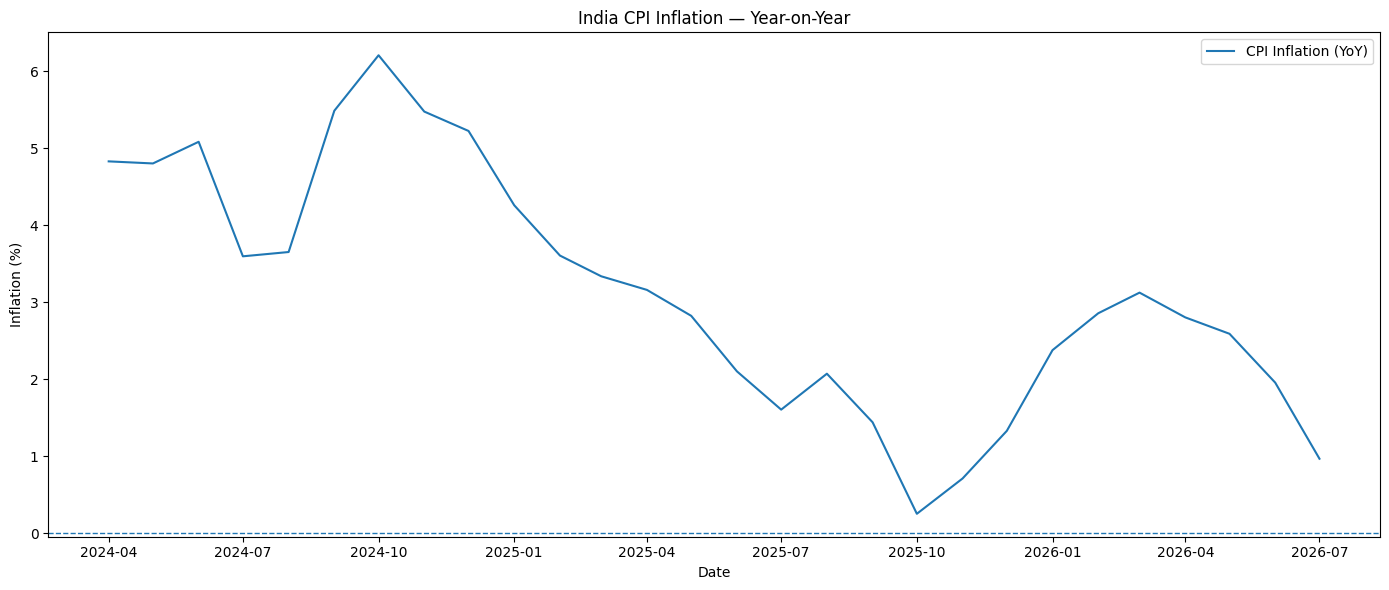

In [4]:
plt.figure(figsize=(14, 6))

plt.plot(
    model_data["date"],
    model_data["cpi_yoy"],
    label="CPI Inflation (YoY)"
)

plt.axhline(
    y=0,
    linestyle="--",
    linewidth=1
)

plt.title("India CPI Inflation — Year-on-Year")
plt.xlabel("Date")
plt.ylabel("Inflation (%)")
plt.legend()
plt.tight_layout()
plt.show()

In [5]:
highest = model_data.nlargest(
    10,
    "cpi_yoy"
)[
    ["date", "cpi_yoy"]
]

lowest = model_data.nsmallest(
    10,
    "cpi_yoy"
)[
    ["date", "cpi_yoy"]
]

print("Highest CPI inflation:")
display(highest)

print("\nLowest CPI inflation:")
display(lowest)

Highest CPI inflation:


,date,cpi_yoy
6,2024-10-01,6.206152
5,2024-09-01,5.486149
7,2024-11-01,5.475040
8,2024-12-01,5.223479
2,2024-06-01,5.082873
0,2024-04-01,4.828748
1,2024-05-01,4.801787
9,2025-01-01,4.258760
4,2024-08-01,3.651987
10,2025-02-01,3.606028



Lowest CPI inflation:


,date,cpi_yoy
18,2025-10-01,0.254065
19,2025-11-01,0.712468
27,2026-07-01,0.968893
20,2025-12-01,1.330604
17,2025-09-01,1.441813
15,2025-07-01,1.606218
26,2026-06-01,1.956746
16,2025-08-01,2.072539
14,2025-06-01,2.103049
21,2026-01-01,2.378490


In [6]:
model_data["cpi_ma3"] = (
    model_data["cpi_yoy"]
    .rolling(3)
    .mean()
)

model_data["cpi_ma12"] = (
    model_data["cpi_yoy"]
    .rolling(12)
    .mean()
)

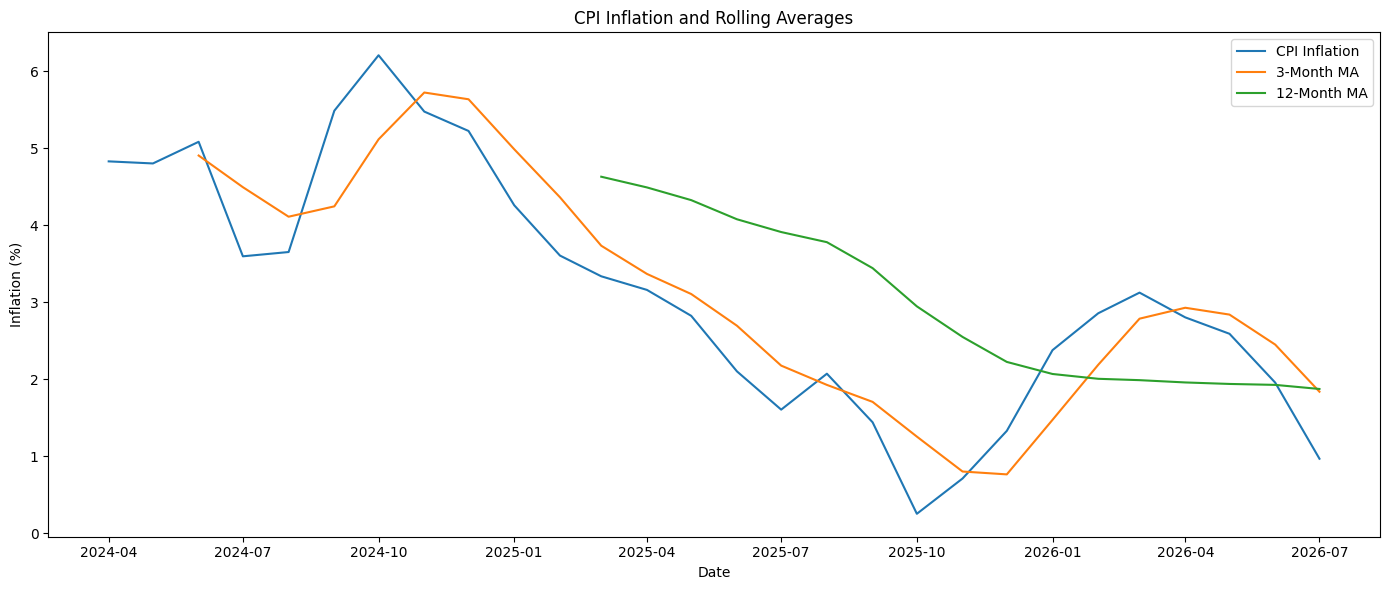

In [7]:
plt.figure(figsize=(14, 6))

plt.plot(
    model_data["date"],
    model_data["cpi_yoy"],
    label="CPI Inflation"
)

plt.plot(
    model_data["date"],
    model_data["cpi_ma3"],
    label="3-Month MA"
)

plt.plot(
    model_data["date"],
    model_data["cpi_ma12"],
    label="12-Month MA"
)

plt.title("CPI Inflation and Rolling Averages")
plt.xlabel("Date")
plt.ylabel("Inflation (%)")
plt.legend()
plt.tight_layout()
plt.show()

In [8]:
model_data["cpi_volatility_12m"] = (
    model_data["cpi_yoy"]
    .rolling(12)
    .std()
)

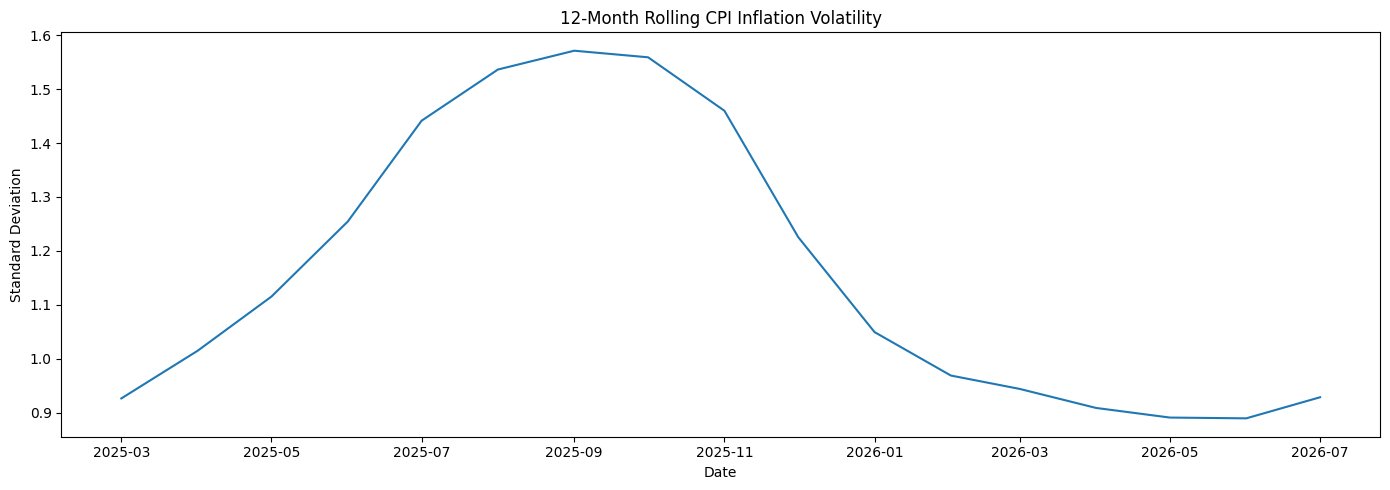

In [9]:
plt.figure(figsize=(14, 5))

plt.plot(
    model_data["date"],
    model_data["cpi_volatility_12m"]
)

plt.title("12-Month Rolling CPI Inflation Volatility")
plt.xlabel("Date")
plt.ylabel("Standard Deviation")
plt.tight_layout()
plt.show()

In [10]:
model_data["month_num"] = (
    model_data["date"].dt.month
)

model_data["month_name"] = (
    model_data["date"].dt.month_name()
)
monthly_seasonality = (
    model_data
    .groupby(["month_num", "month_name"])["cpi_yoy"]
    .mean()
    .reset_index()
    .sort_values("month_num")
)

display(monthly_seasonality)

,month_num,month_name,cpi_yoy
0,1,January,3.318625
1,2,February,3.231585
2,3,March,3.230961
3,4,April,3.597545
4,5,May,3.405372
5,6,June,3.047556
6,7,July,2.057154
7,8,August,2.862263
8,9,September,3.463981
9,10,October,3.230109


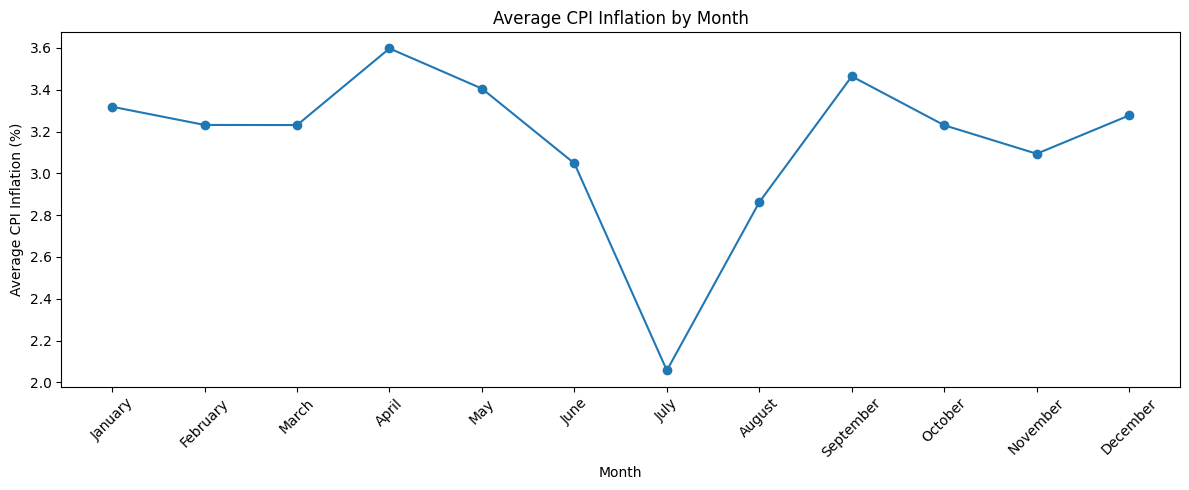

In [11]:
plt.figure(figsize=(12, 5))

plt.plot(
    monthly_seasonality["month_name"],
    monthly_seasonality["cpi_yoy"],
    marker="o"
)

plt.title("Average CPI Inflation by Month")
plt.xlabel("Month")
plt.ylabel("Average CPI Inflation (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

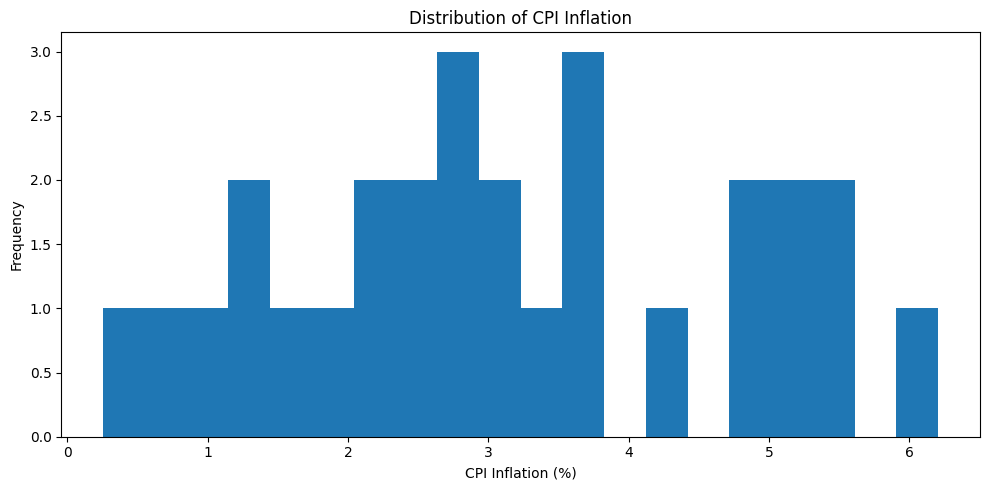

In [12]:
plt.figure(figsize=(10, 5))

plt.hist(
    model_data["cpi_yoy"].dropna(),
    bins=20
)

plt.title("Distribution of CPI Inflation")
plt.xlabel("CPI Inflation (%)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

In [13]:
print(
    model_data["cpi_yoy"].skew()
)

print(
    model_data["cpi_yoy"].kurt()
)

0.15487087013322012
-0.7968611152828733


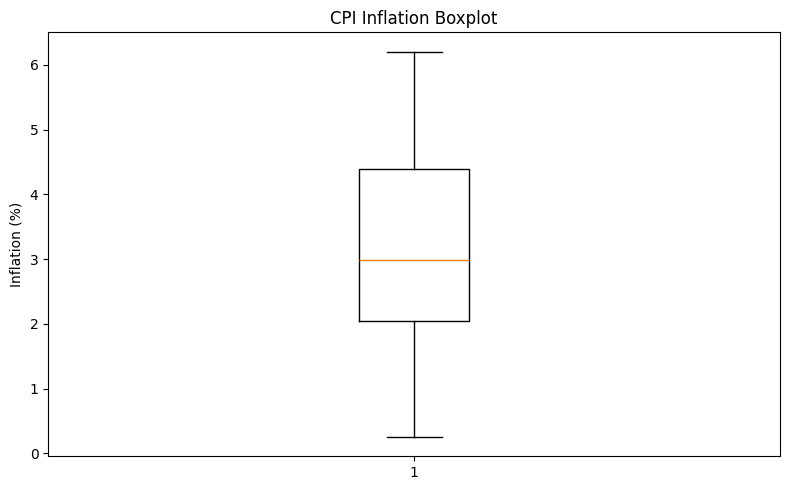

In [14]:
plt.figure(figsize=(8, 5))

plt.boxplot(
    model_data["cpi_yoy"].dropna(),
    vert=True
)

plt.title("CPI Inflation Boxplot")
plt.ylabel("Inflation (%)")
plt.tight_layout()
plt.show()

In [15]:
corr_vars = [
    "cpi_yoy",
    "wpi_all_yoy",
    "wpi_primary_yoy",
    "wpi_fuel_yoy",
    "wpi_manufacturing_yoy"
]

correlation_matrix = (
    model_data[corr_vars]
    .corr()
)

display(correlation_matrix)

,cpi_yoy,wpi_all_yoy,wpi_primary_yoy,wpi_fuel_yoy,wpi_manufacturing_yoy
cpi_yoy,1.000000,-0.021397,0.739194,-0.229403,-0.430209
wpi_all_yoy,-0.021397,1.000000,0.565064,0.944587,0.872359
wpi_primary_yoy,0.739194,0.565064,1.000000,0.344457,0.125075
wpi_fuel_yoy,-0.229403,0.944587,0.344457,1.000000,0.879976
wpi_manufacturing_yoy,-0.430209,0.872359,0.125075,0.879976,1.000000


In [16]:
lag_results = []

for lag in range(13):

    temp = pd.DataFrame({
        "cpi": model_data["cpi_yoy"],
        "wpi_lagged": model_data["wpi_all_yoy"].shift(lag)
    }).dropna()

    corr = temp["cpi"].corr(
        temp["wpi_lagged"]
    )

    lag_results.append({
        "lag_months": lag,
        "correlation": corr
    })

lag_corr = pd.DataFrame(lag_results)

display(lag_corr)

,lag_months,correlation
0,0,-0.021397
1,1,-0.019328
2,2,-0.003447
3,3,0.111902
4,4,0.357350
5,5,0.403324
6,6,0.323867
7,7,0.202210
8,8,0.061238
9,9,-0.062190


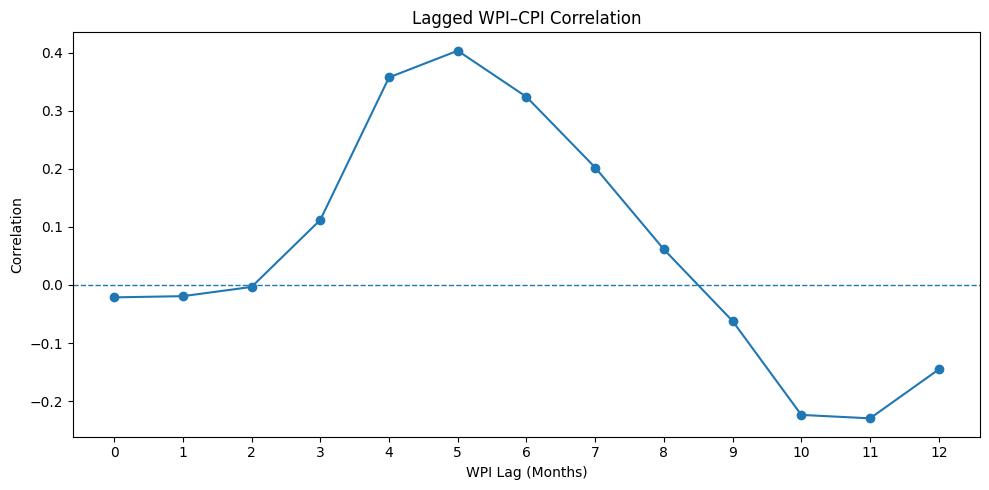

In [17]:
plt.figure(figsize=(10, 5))

plt.plot(
    lag_corr["lag_months"],
    lag_corr["correlation"],
    marker="o"
)

plt.axhline(
    0,
    linestyle="--",
    linewidth=1
)

plt.title("Lagged WPI–CPI Correlation")
plt.xlabel("WPI Lag (Months)")
plt.ylabel("Correlation")
plt.xticks(range(13))
plt.tight_layout()
plt.show()

In [18]:
model_ppi = pd.read_csv(
    r"C:\Users\Adity\OneDrive\Desktop\RESEARCH\Project Work\Inflation-Forecasting-Dashboard\data\processed\model_sample_cpi_wpi_ppi.csv",
    parse_dates=["date"]
)

print(model_ppi.shape)
display(model_ppi.head())

(28, 13)


,date,cpi_combined,cpi_yoy,wpi_all,wpi_primary,wpi_fuel,wpi_manufacturing,wpi_all_yoy,wpi_primary_yoy,wpi_fuel_yoy,wpi_manufacturing_yoy,output_ppi,output_ppi_yoy
0,2024-04-01,186.7,4.828748,99.9,108.8,92.0,98.5,0.909091,6.666667,-2.127660,-0.605449,99.7,0.605449
1,2024-05-01,187.7,4.801787,100.4,110.1,91.7,98.9,1.825558,7.624633,0.328228,0.000000,100.1,1.521298
2,2024-06-01,190.2,5.082873,100.7,111.8,89.9,99.1,2.441506,8.228461,-0.662983,0.916497,100.4,2.240326
3,2024-07-01,193.0,3.596350,101.0,113.1,91.2,98.8,1.917255,4.819277,0.662252,1.022495,100.8,1.715439
4,2024-08-01,193.0,3.651987,100.8,113.8,90.9,98.4,1.306533,5.370370,-0.980392,0.305810,100.7,1.307847


In [19]:
ppi_corr = model_ppi[
    [
        "cpi_yoy",
        "wpi_all_yoy",
        "output_ppi_yoy"
    ]
].corr()

display(ppi_corr)

,cpi_yoy,wpi_all_yoy,output_ppi_yoy
cpi_yoy,1.000000,-0.021397,-0.060245
wpi_all_yoy,-0.021397,1.000000,0.998164
output_ppi_yoy,-0.060245,0.998164,1.000000


In [20]:
lag_ppi_results = []

for lag in range(13):

    temp = pd.DataFrame({
        "cpi": model_ppi["cpi_yoy"],
        "ppi_lagged": model_ppi["output_ppi_yoy"].shift(lag)
    }).dropna()

    corr = temp["cpi"].corr(
        temp["ppi_lagged"]
    )

    lag_ppi_results.append({
        "lag_months": lag,
        "correlation": corr
    })

lag_ppi_corr = pd.DataFrame(
    lag_ppi_results
)

display(lag_ppi_corr)

,lag_months,correlation
0,0,-0.060245
1,1,-0.063210
2,2,-0.057499
3,3,0.040300
4,4,0.243895
5,5,0.277411
6,6,0.182977
7,7,0.051413
8,8,-0.085958
9,9,-0.202530


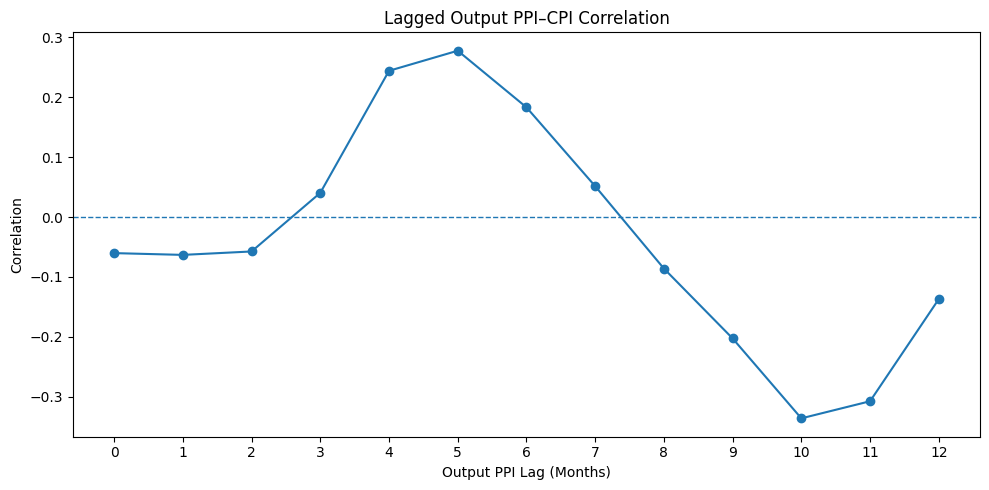

In [21]:
plt.figure(figsize=(10, 5))

plt.plot(
    lag_ppi_corr["lag_months"],
    lag_ppi_corr["correlation"],
    marker="o"
)

plt.axhline(
    0,
    linestyle="--",
    linewidth=1
)

plt.title("Lagged Output PPI–CPI Correlation")
plt.xlabel("Output PPI Lag (Months)")
plt.ylabel("Correlation")
plt.xticks(range(13))
plt.tight_layout()
plt.show()

In [22]:
model_data["month_num"] = model_data["date"].dt.month
model_data["month_name"] = model_data["date"].dt.month_name()

monthly_seasonality = (
    model_data
    .groupby(["month_num", "month_name"])["cpi_yoy"]
    .mean()
    .reset_index()
    .sort_values("month_num")
)

display(monthly_seasonality)

,month_num,month_name,cpi_yoy
0,1,January,3.318625
1,2,February,3.231585
2,3,March,3.230961
3,4,April,3.597545
4,5,May,3.405372
5,6,June,3.047556
6,7,July,2.057154
7,8,August,2.862263
8,9,September,3.463981
9,10,October,3.230109


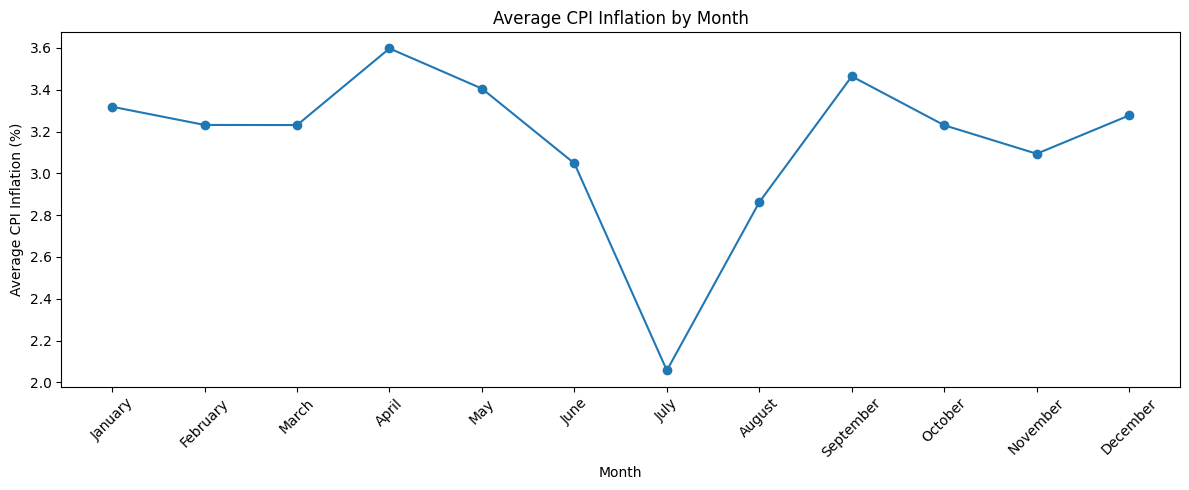

In [23]:
plt.figure(figsize=(12, 5))

plt.plot(
    monthly_seasonality["month_name"],
    monthly_seasonality["cpi_yoy"],
    marker="o"
)

plt.title("Average CPI Inflation by Month")
plt.xlabel("Month")
plt.ylabel("Average CPI Inflation (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

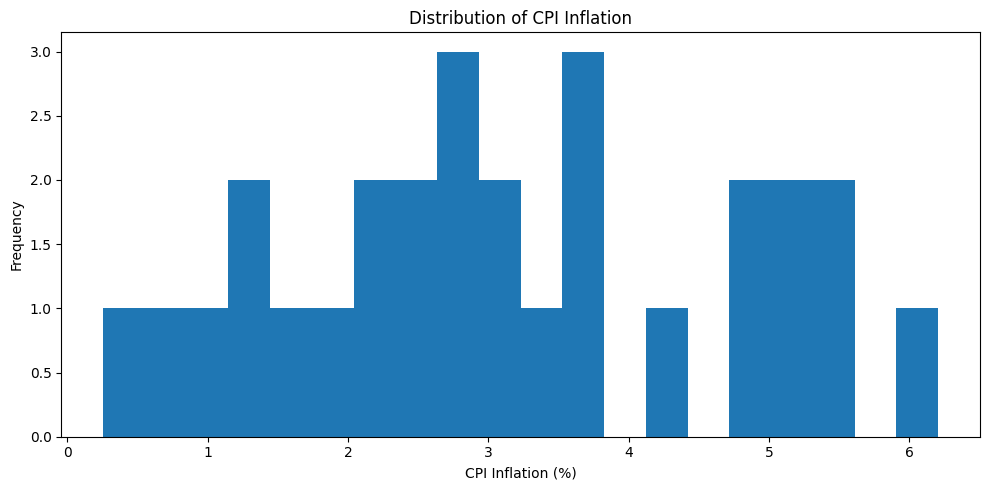

In [24]:
plt.figure(figsize=(10, 5))

plt.hist(
    model_data["cpi_yoy"].dropna(),
    bins=20
)

plt.title("Distribution of CPI Inflation")
plt.xlabel("CPI Inflation (%)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

In [25]:
print("Skewness:",
      model_data["cpi_yoy"].skew())

print("Kurtosis:",
      model_data["cpi_yoy"].kurt())

Skewness: 0.15487087013322012
Kurtosis: -0.7968611152828733


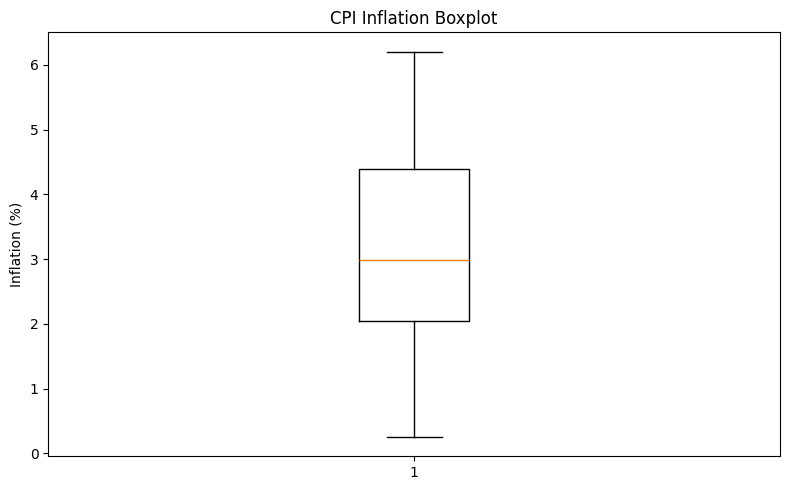

In [26]:
plt.figure(figsize=(8, 5))

plt.boxplot(
    model_data["cpi_yoy"].dropna()
)

plt.title("CPI Inflation Boxplot")
plt.ylabel("Inflation (%)")
plt.tight_layout()
plt.show()

In [27]:
corr_vars = [
    "cpi_yoy",
    "wpi_all_yoy",
    "wpi_primary_yoy",
    "wpi_fuel_yoy",
    "wpi_manufacturing_yoy"
]

correlation_matrix = model_data[corr_vars].corr()

display(correlation_matrix)

,cpi_yoy,wpi_all_yoy,wpi_primary_yoy,wpi_fuel_yoy,wpi_manufacturing_yoy
cpi_yoy,1.000000,-0.021397,0.739194,-0.229403,-0.430209
wpi_all_yoy,-0.021397,1.000000,0.565064,0.944587,0.872359
wpi_primary_yoy,0.739194,0.565064,1.000000,0.344457,0.125075
wpi_fuel_yoy,-0.229403,0.944587,0.344457,1.000000,0.879976
wpi_manufacturing_yoy,-0.430209,0.872359,0.125075,0.879976,1.000000


In [28]:
lag_results = []

for lag in range(13):

    temp = pd.DataFrame({
        "cpi": model_data["cpi_yoy"],
        "wpi_lagged": model_data["wpi_all_yoy"].shift(lag)
    }).dropna()

    correlation = temp["cpi"].corr(
        temp["wpi_lagged"]
    )

    lag_results.append({
        "lag_months": lag,
        "correlation": correlation
    })

lag_corr = pd.DataFrame(lag_results)

display(lag_corr)

,lag_months,correlation
0,0,-0.021397
1,1,-0.019328
2,2,-0.003447
3,3,0.111902
4,4,0.357350
5,5,0.403324
6,6,0.323867
7,7,0.202210
8,8,0.061238
9,9,-0.062190


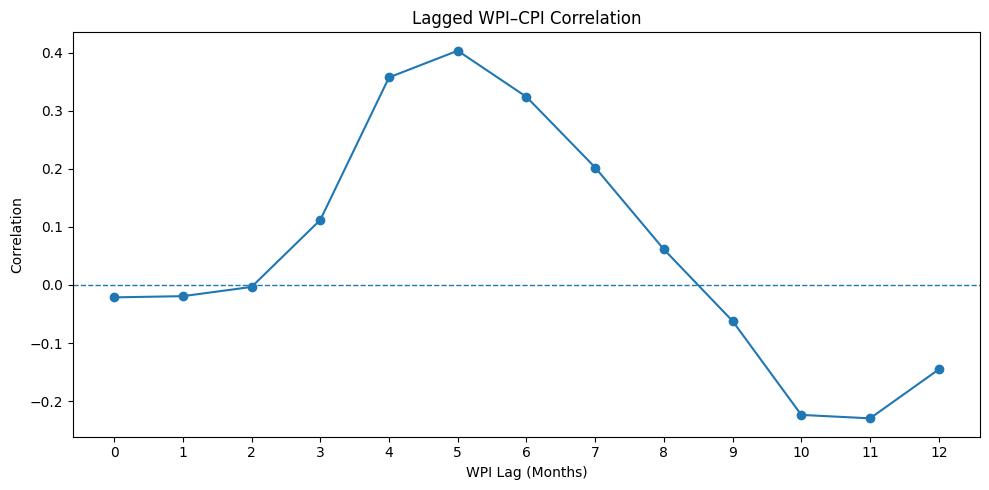

In [29]:
plt.figure(figsize=(10, 5))

plt.plot(
    lag_corr["lag_months"],
    lag_corr["correlation"],
    marker="o"
)

plt.axhline(
    0,
    linestyle="--",
    linewidth=1
)

plt.title("Lagged WPI–CPI Correlation")
plt.xlabel("WPI Lag (Months)")
plt.ylabel("Correlation")
plt.xticks(range(13))
plt.tight_layout()
plt.show()

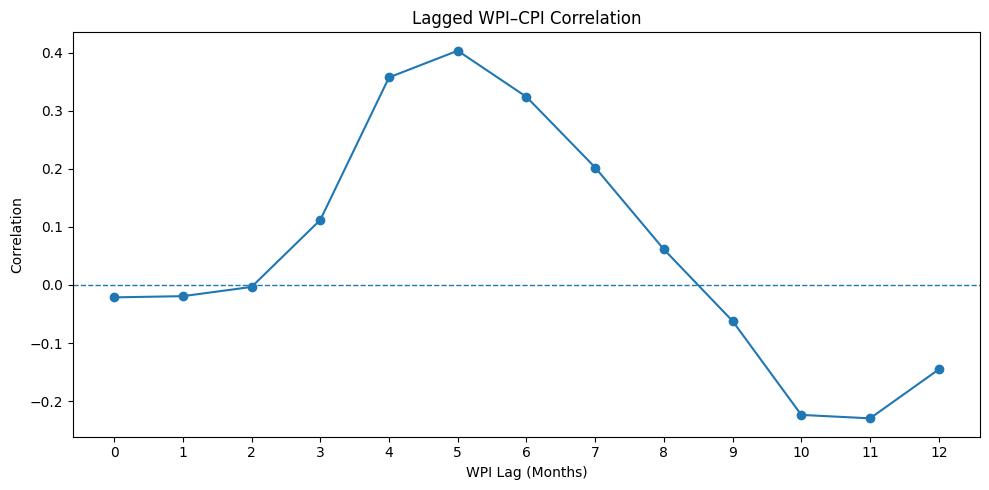

In [30]:
plt.figure(figsize=(10, 5))

plt.plot(
    lag_corr["lag_months"],
    lag_corr["correlation"],
    marker="o"
)

plt.axhline(
    0,
    linestyle="--",
    linewidth=1
)

plt.title("Lagged WPI–CPI Correlation")
plt.xlabel("WPI Lag (Months)")
plt.ylabel("Correlation")
plt.xticks(range(13))
plt.tight_layout()
plt.show()

In [31]:
model_ppi = pd.read_csv(
    r"C:\Users\Adity\OneDrive\Desktop\RESEARCH\Project Work\Inflation-Forecasting-Dashboard\data\processed\model_sample_cpi_wpi_ppi.csv",
    parse_dates=["date"]
)

print("Shape:", model_ppi.shape)

display(model_ppi.head())
display(model_ppi.tail())

Shape: (28, 13)


,date,cpi_combined,cpi_yoy,wpi_all,wpi_primary,wpi_fuel,wpi_manufacturing,wpi_all_yoy,wpi_primary_yoy,wpi_fuel_yoy,wpi_manufacturing_yoy,output_ppi,output_ppi_yoy
0,2024-04-01,186.7,4.828748,99.9,108.8,92.0,98.5,0.909091,6.666667,-2.127660,-0.605449,99.7,0.605449
1,2024-05-01,187.7,4.801787,100.4,110.1,91.7,98.9,1.825558,7.624633,0.328228,0.000000,100.1,1.521298
2,2024-06-01,190.2,5.082873,100.7,111.8,89.9,99.1,2.441506,8.228461,-0.662983,0.916497,100.4,2.240326
3,2024-07-01,193.0,3.596350,101.0,113.1,91.2,98.8,1.917255,4.819277,0.662252,1.022495,100.8,1.715439
4,2024-08-01,193.0,3.651987,100.8,113.8,90.9,98.4,1.306533,5.370370,-0.980392,0.305810,100.7,1.307847


,date,cpi_combined,cpi_yoy,wpi_all,wpi_primary,wpi_fuel,wpi_manufacturing,wpi_all_yoy,wpi_primary_yoy,wpi_fuel_yoy,wpi_manufacturing_yoy,output_ppi,output_ppi_yoy
23,2026-03-01,NaN,3.125000,104.6,111.4,93.5,104.7,3.976143,2.578269,3.200883,4.804805,104.9,4.170804
24,2026-04-01,NaN,2.803738,108.9,112.8,111.0,107.0,8.358209,3.963134,25.000000,6.679960,108.8,8.258706
25,2026-05-01,NaN,2.590674,110.1,114.0,113.4,108.0,9.880240,5.263158,30.795848,7.676969,109.9,9.680639
26,2026-06-01,NaN,1.956746,110.2,116.1,111.1,107.8,9.870389,7.004608,27.408257,7.477567,109.9,9.571286
27,2026-07-01,NaN,0.968893,110.0,117.2,105.4,108.4,9.780439,8.518519,20.045558,8.291708,109.9,9.571286


In [32]:
ppi_corr = model_ppi[
    [
        "cpi_yoy",
        "wpi_all_yoy",
        "output_ppi_yoy"
    ]
].corr()

display(ppi_corr)

,cpi_yoy,wpi_all_yoy,output_ppi_yoy
cpi_yoy,1.000000,-0.021397,-0.060245
wpi_all_yoy,-0.021397,1.000000,0.998164
output_ppi_yoy,-0.060245,0.998164,1.000000


In [33]:
lag_ppi_results = []

for lag in range(13):

    temp = pd.DataFrame({
        "cpi": model_ppi["cpi_yoy"],
        "ppi_lagged": model_ppi["output_ppi_yoy"].shift(lag)
    }).dropna()

    correlation = temp["cpi"].corr(
        temp["ppi_lagged"]
    )

    lag_ppi_results.append({
        "lag_months": lag,
        "correlation": correlation
    })

lag_ppi_corr = pd.DataFrame(
    lag_ppi_results
)

display(lag_ppi_corr)

,lag_months,correlation
0,0,-0.060245
1,1,-0.063210
2,2,-0.057499
3,3,0.040300
4,4,0.243895
5,5,0.277411
6,6,0.182977
7,7,0.051413
8,8,-0.085958
9,9,-0.202530


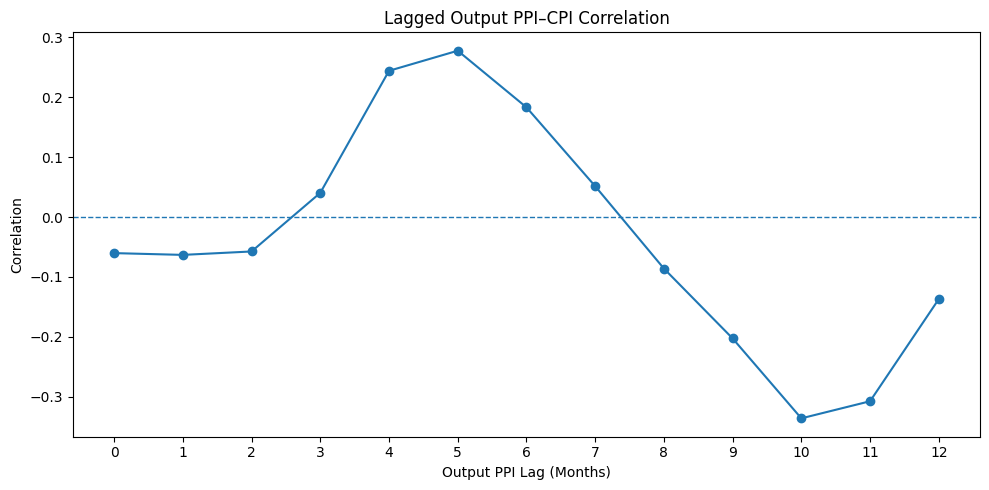

In [34]:
plt.figure(figsize=(10, 5))

plt.plot(
    lag_ppi_corr["lag_months"],
    lag_ppi_corr["correlation"],
    marker="o"
)

plt.axhline(
    0,
    linestyle="--",
    linewidth=1
)

plt.title("Lagged Output PPI–CPI Correlation")
plt.xlabel("Output PPI Lag (Months)")
plt.ylabel("Correlation")
plt.xticks(range(13))
plt.tight_layout()
plt.show()

In [35]:
max_wpi = lag_corr.loc[
    lag_corr["correlation"].idxmax()
]

max_ppi = lag_ppi_corr.loc[
    lag_ppi_corr["correlation"].idxmax()
]

print("Strongest WPI-CPI lag:")
print(max_wpi)

print("\nStrongest PPI-CPI lag:")
print(max_ppi)

Strongest WPI-CPI lag:
lag_months     5.000000
correlation    0.403324
Name: 5, dtype: float64

Strongest PPI-CPI lag:
lag_months     5.000000
correlation    0.277411
Name: 5, dtype: float64


## EDA Conclusions

### CPI Dynamics
- CPI inflation exhibits [high/moderate/low] persistence.
- Inflation volatility varies across the sample.
- [Evidence/no clear evidence] of monthly seasonality is observed.
- Several high/low inflation episodes are visible.

### CPI–WPI Relationship
- Contemporaneous CPI-WPI correlation is ...
- The strongest lagged WPI-CPI correlation occurs at ... months.
- This provides preliminary evidence of predictive co-movement, but not causality.

### CPI–PPI Relationship
- CPI-Output PPI correlation is ...
- The strongest lagged relationship occurs at ... months.
- Because the PPI sample is relatively short, these findings should be treated as preliminary.

### Implications for Modelling
- CPI's persistence motivates autoregressive models.
- Any detected seasonality motivates testing SARIMA.
- WPI and PPI lags provide candidates for SARIMAX predictors.
- Final model selection will be based on rolling out-of-sample performance rather than in-sample correlation.